In [1]:
# import libraries needed for the analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import mean_squared_log_error
import re

import lightgbm as lgb
from lightgbm import LGBMRegressor


In [2]:
#Load datasets
train = pd.read_csv('train.csv')
store = pd.read_csv('stores.csv')
transaction = pd.read_csv('transactions.csv')
oil = pd.read_csv('oil.csv')
holiday = pd.read_csv('holidays_events.csv')
test = pd.read_csv('test.csv')

# Convert dates
train["date"] = pd.to_datetime(train["date"])
transaction["date"] = pd.to_datetime(transaction["date"])
holiday["date"] = pd.to_datetime(holiday["date"])
oil["date"] = pd.to_datetime(oil["date"])
test["date"] = pd.to_datetime(test["date"])


In [3]:
# helper function to print messages
def cprint(title, *args):
    print(
        "="*len(title), title, "="*len(title),
        *args,
        sep="\n",
    )

In [4]:
# date range function 
def date_range(name, df):
    return f"{name}: {df['date'].min().date()} to {df['date'].max().date()}"

In [5]:
def create_store_holiday_sales_tables(train, store, holiday):

    # Create daily sales by store
    daily_store_sales = (
        train.groupby(["date", "store_nbr"], as_index=False)["sales"]
        .sum()
    )

    # Add city and state
    daily_store_sales = daily_store_sales.merge(
        store[["store_nbr", "city", "state"]],
        on="store_nbr",
        how="left"
    )

    # Keep actual holidays only
    true_holiday = holiday[(
        (holiday["transferred"] == False) &
        (holiday["type"] != "Work Day"))
    |   # Include Jan 1 as a holiday because some New Year's Day records were marked as transferred
        ((holiday["date"].dt.month == 1) &(holiday["date"].dt.day == 1))
    ].copy()

    # Merge holiday information
    holiday_check = daily_store_sales[["date", "store_nbr", "city", "state"]].merge(
        true_holiday[["date", "locale", "locale_name"]],
        on="date",
        how="left"
    )

    # Store-specific holiday logic
    holiday_check["holiday_match"] = (
        (holiday_check["locale"] == "National") |
        ((holiday_check["locale"] == "Regional") &
         (holiday_check["state"] == holiday_check["locale_name"])) |
        ((holiday_check["locale"] == "Local") &
         (holiday_check["city"] == holiday_check["locale_name"]))
    ).fillna(False)

    # Collapse duplicate holiday rows
    holiday_lookup = (
        holiday_check
        .groupby(["date", "store_nbr"], as_index=False)
        .agg(is_holiday=("holiday_match", "max"))
    )

    # Merge holiday flag back
    daily_store_sales = daily_store_sales.merge(
        holiday_lookup,
        on=["date", "store_nbr"],
        how="left"
    )

    daily_store_sales["is_holiday"] = daily_store_sales["is_holiday"].fillna(False).astype(int)

    # Add labels
    daily_store_sales["year"] = daily_store_sales["date"].dt.year
    daily_store_sales["holiday_label"] = daily_store_sales["is_holiday"].map({
        0: "Non-Holiday",
        1: "Holiday"
    })

    # Split holiday / non-holiday store daily sales
    store_daily_sales_holiday = daily_store_sales[
        daily_store_sales["is_holiday"] == 1
    ].copy()

    store_daily_sales_not_holiday = daily_store_sales[
        daily_store_sales["is_holiday"] == 0
    ].copy()

    # Split zero-sales holiday / non-holiday
    zero_sales_holiday = daily_store_sales[
        (daily_store_sales["sales"] == 0) &
        (daily_store_sales["is_holiday"] == 1)
    ].copy()

    zero_sales_not_holiday = daily_store_sales[
        (daily_store_sales["sales"] == 0) &
        (daily_store_sales["is_holiday"] == 0)
    ].copy()

    # Summary
    summary = {
        "total_store_daily_sales_rows": len(daily_store_sales),
        "store_daily_sales_on_holiday": len(store_daily_sales_holiday),
        "store_daily_sales_not_holiday": len(store_daily_sales_not_holiday),
        "zero_sales_holiday": len(zero_sales_holiday),
        "zero_sales_not_holiday": len(zero_sales_not_holiday)
    }

    return (
        daily_store_sales,
        store_daily_sales_holiday,
        store_daily_sales_not_holiday,
        zero_sales_holiday,
        zero_sales_not_holiday,
        summary
    )

daily_store_sales, store_daily_sales_holiday, store_daily_sales_not_holiday, zero_sales_holiday, zero_sales_not_holiday, summary = create_store_holiday_sales_tables(
    train, store, holiday
)

summary

{'total_store_daily_sales_rows': 90936,
 'store_daily_sales_on_holiday': 7506,
 'store_daily_sales_not_holiday': 83430,
 'zero_sales_holiday': 756,
 'zero_sales_not_holiday': 6574}

In [6]:
def clean_feature_names(df):
    df = df.copy()
    df.columns = [
        re.sub(r"[^A-Za-z0-9_]+", "_", str(col)) for col in df.columns
    ]
    return df

# Data Exploration and Preprocessing

### 1. Check Date Range of Each Dataset

First things first, We want to get an overview of how records alight across datasets, datasets cover the training period, which datasets extend into the test period, and whether any date gaps may need to be addressed during data preparation.

In [7]:
cprint(
    "Date Range Overview",
    date_range("train", train),
    date_range("test", test),
    date_range("transaction", transaction),
    date_range("oil", oil),
    date_range("holiday", holiday)
)

Date Range Overview
train: 2013-01-01 to 2017-08-15
test: 2017-08-16 to 2017-08-31
transaction: 2013-01-01 to 2017-08-15
oil: 2013-01-01 to 2017-08-31
holiday: 2012-03-02 to 2017-12-26


### 2. Check `train.date` for missing dates

In [8]:
# Full date range
full_dates = pd.date_range(train["date"].min(),  train["date"].max(),freq="D")

# Actual unique dates in train.csv
actual_dates = pd.DatetimeIndex(train["date"].drop_duplicates()).sort_values()

# Find missing dates
missing_dates = full_dates.difference(actual_dates)

cprint(
    "Missing Dates Check",
    f"Train date range: {len(full_dates)}",
    f"Actual train dates count: {len(actual_dates)}",
    f"Missing date count: {len(missing_dates)}",
    f"Missing dates: {missing_dates}"
)

Missing Dates Check
Train date range: 1688
Actual train dates count: 1684
Missing date count: 4
Missing dates: DatetimeIndex(['2013-12-25', '2014-12-25', '2015-12-25', '2016-12-25'], dtype='datetime64[ns]', freq=None)


**Comments:** *Four dates were missing from the train dataset, and all occurred on Christmas day(December 25.) Because these dates are likely related holiday closures, they will be  treated as structural missing dates rather than random missing data. These dates will be simply docummented as the analysis does not focus on time-series model.*

###  3. Check Holiday Related 0 Sales 

We found out that there are days where sales == 0, we want to find out how many of days where the 0 sales are due to holiday store closures. 

In [9]:
# 1. Find dates where total sales for the whole dataset = 0
zero_sales_days = daily_store_sales[daily_store_sales["sales"] == 0]

cprint(
    "Zero Sales Days",
    f"Zero-sales day count: {len(zero_sales_days)}",
    f"Zero sales on holidays: {len(zero_sales_holiday)}",
    f"Zero sales not on holidays: {len(zero_sales_not_holiday)}"
    )

Zero Sales Days
Zero-sales day count: 7330
Zero sales on holidays: 756
Zero sales not on holidays: 6574


### 4.  Check and Invastigate Stores with 0 Sale Days

Before making decisons on how to deal with these 0 sales records, we want to find out reasons or patterns in order oto identify best practice dealing with these records. 

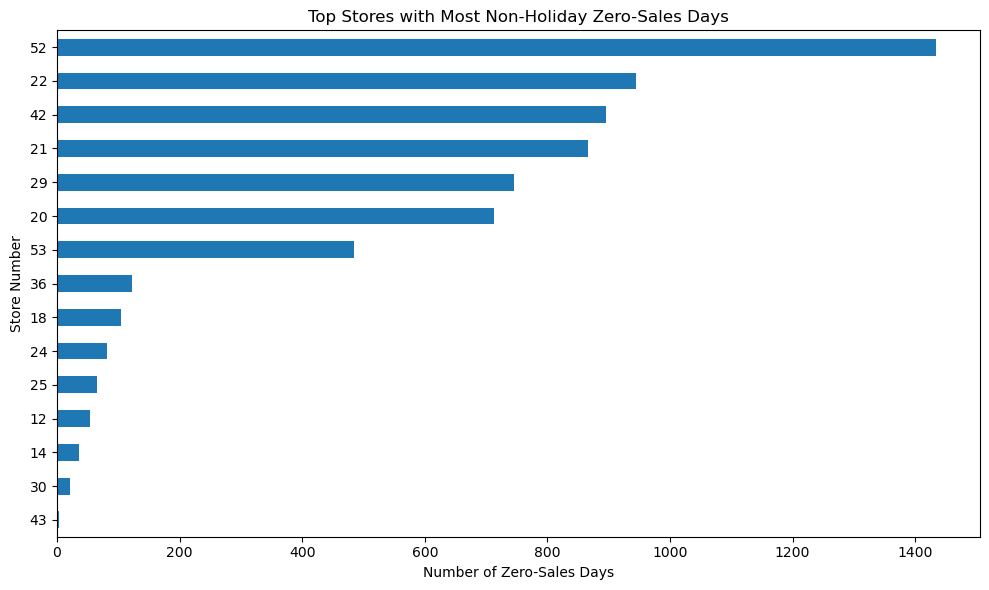

In [10]:
# Find out and sort Stores with total 0 sales days
zero_sales_not_holiday_by_store = (
    zero_sales_not_holiday
    .groupby("store_nbr")
    .size()
    .reset_index(name="zero_sales_days")
    .sort_values("zero_sales_days", ascending=False)
)

# We choose fisrt 15 0 sales stores.
top_zero_sales_stores = (
    zero_sales_not_holiday_by_store
    .head(15)
    .set_index("store_nbr")["zero_sales_days"]
    .sort_values()
)

plt.figure(figsize=(10, 6))

top_zero_sales_stores.plot(kind="barh")

plt.title("Top Stores with Most Non-Holiday Zero-Sales Days")
plt.xlabel("Number of Zero-Sales Days")
plt.ylabel("Store Number")
plt.tight_layout()
plt.show()

**Comment:** *The top 15 stores with quite 0 sales days are shown above. The assumption is these stores might not be officially open before  their first sales. We will find out in the codes below.*

In [11]:
# First positive sales date for each store
first_sales_date = (
    daily_store_sales[daily_store_sales["sales"] > 0]
    .groupby("store_nbr")["date"]
    .min()
    .reset_index()
    .rename(columns={"date": "first_sales_date"})
)

# Add first sales date to zero_sales_not_holiday
zero_sales_stores = zero_sales_not_holiday.merge(
    first_sales_date,
    on="store_nbr",
    how="left"
)

# Check if zero sales happened before first positive sale
zero_sales_stores["before_first_sale"] = (
    zero_sales_stores["date"] < zero_sales_stores["first_sales_date"]
)

# Count by store
pre_open_zero_by_store = (
    zero_sales_stores
    .groupby("store_nbr", as_index=False)
    .agg(
        zero_sales_days=("date", "count"),
        before_first_sale_days=("before_first_sale", "sum"),
        first_sales_date=("first_sales_date", "min")).sort_values("zero_sales_days", ascending=False)
    .reset_index(drop = True)
)
pre_open_zero_by_store

,store_nbr,zero_sales_days,before_first_sale_days,first_sales_date
0,52,1434,1434,2017-04-20
1,22,945,945,2015-10-09
2,42,895,895,2015-08-21
3,21,866,866,2015-07-24
4,29,746,746,2015-03-20
5,20,713,713,2015-02-13
6,53,484,484,2014-05-29
7,36,122,122,2013-05-09
8,18,104,0,2013-01-02
9,24,82,0,2013-01-02


**Comments:**:*This table compares non-holiday zero-sales days with each store’s first positive sales date. Stores such as 52, 22, 42, 21, 29, 20, 53, and 36 had most or all of their zero-sales days before their first positive sales date, suggesting these records were likely pre-opening or inactive-store periods. These inactive records will be removed from model training. Stores with zero before-first-sale days had zero sales after becoming active, so those records will be kept as valid business observations.*

In [12]:
# Stores with pre-opening / inactive zero-sales records
inactive_store= pre_open_zero_by_store[
    pre_open_zero_by_store["before_first_sale_days"] > 0
][["store_nbr", "first_sales_date"]]

# Add first sales date to train
train_clean = train.merge(
    inactive_store,
    on="store_nbr",
    how="left"
)

# Remove rows before first positive sales date
train_clean = train_clean[
    train_clean["first_sales_date"].isna() |
    (train_clean["date"] >= train_clean["first_sales_date"])
].copy()

# Drop helper column
train_clean = train_clean.drop(columns=["first_sales_date"])

train_clean.shape, train.shape

((2780316, 6), (3000888, 6))

### 4. Check Missing Oil price

There are missing oil price records on weekend

In [13]:
oil.isna().sum()

date           0
dcoilwtico    43
dtype: int64

In [14]:
# Change the price column name for clarity
oil = oil.rename(columns={"dcoilwtico": "oil_price"})

In [15]:
#find dates that dont exist in oil dataset from start of train to the end of the test 
missing_oil_dates =full_dates.difference(oil.date)

#calculate the missing days in oil dataset
num_missing_oil_dates = len(missing_oil_dates)

# calculate how many missing days are in the weekend
num_wknd_missing = (missing_oil_dates.weekday >= 5).sum()

cprint(
    "Missing Oil Dates Check",
    f"Missing oil date count: {num_missing_oil_dates}",
    f"Missing oil dates on weekends: {num_wknd_missing}",
    f"Missing oil dates not on weekends: {num_missing_oil_dates - num_wknd_missing}"
)


Missing Oil Dates Check
Missing oil date count: 482
Missing oil dates on weekends: 482
Missing oil dates not on weekends: 0


In [16]:
# Create full daily date range for your modeling period
full_oil_dates = pd.DataFrame({
    "date": pd.date_range(
        start=oil["date"].min(),
        end=oil["date"].max(),
        freq="D"
    )
})


# Merge oil onto full daily calendar
oil_clean = full_oil_dates.merge(oil, on="date", how="left")

# Fill missing weekend oil prices
oil_clean["oil_price"] = oil_clean["oil_price"].ffill().bfill()

# Check missing values after fill
print(oil_clean["oil_price"].isna().sum())

0


**Comments**: *Missing oil price dates were reviewed and all missing oil records occurred on weekends. Since oil prices are typically not reported on non-trading days, the missing values are filled using forward fill based on the most recent available oil price, in order to aligh with sales data.* 

## Store Information

In [17]:
num_stores = store["store_nbr"].nunique()

In [18]:
# Check shape
print("Stores rows and columns:", store.shape)
print("Unique stores:", store["store_nbr"].nunique())
print("Unique cities:", store["city"].nunique())
print("Unique states:", store["state"].nunique())
print("Unique store types:", store["type"].nunique())
print("Unique clusters:", store["cluster"].nunique())

Stores rows and columns: (54, 5)
Unique stores: 54
Unique cities: 22
Unique states: 16
Unique store types: 5
Unique clusters: 17


In [19]:
store.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54 entries, 0 to 53
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   store_nbr  54 non-null     int64 
 1   city       54 non-null     object
 2   state      54 non-null     object
 3   type       54 non-null     object
 4   cluster    54 non-null     int64 
dtypes: int64(2), object(3)
memory usage: 2.2+ KB


In [20]:
store["cluster"] = store["cluster"].astype(str)

## Transaction information

The transactions dataset are compared with `tran_clean`and is discovered a total of 764 store-date  missing transaction records. Of these, 118 records had positive sales, which indicates incomplete transaction data. Because transactions are not used in the forecasting model, these records will be removed from file that only is used for Power bi visualization.  The remaining missing records are  will be kept as `NaN` rather than filled with 0, so the visualization does not treat missing transaction data as confirmed zero transactions.

In [21]:
# Create store-date level sales table from cleaned train data
daily_store_sales_clean = (
    train_clean
    .groupby(["date", "store_nbr"], as_index=False)
    .agg(
        total_sales=("sales", "sum"),
        total_promotion=("onpromotion", "sum")
    )
)

# Merge transaction data by date and store
transaction_updated = daily_store_sales_clean.merge(
    transaction,
    on=["date", "store_nbr"],
    how="left"
)

# Identify problematic records:
# sales > 0 but transaction is missing
missing_transaction_with_sales = transaction_updated[
    (transaction_updated["transactions"].isna()) &
    (transaction_updated["total_sales"] > 0)]

In [22]:
cprint('Missing Transaction Breakdown',
       f'Missing transaction: {transaction_updated['transactions'].isna().sum()}',
       f'Missing positive sales transaciton: {len(missing_transaction_with_sales)}')


Missing Transaction Breakdown
Missing transaction: 764
Missing positive sales transaciton: 118


In [24]:
# Create a cleaned transaction file for visualization
# missing positive sales will be removed for the accuracy. 
transaction_clean = transaction_updated[
    ~(
        (transaction_updated["transactions"].isna()) &
        (transaction_updated["total_sales"] > 0)
    )
].copy()


# Check result
cprint(
    "Transaction Cleaning Summary",
    f"Final records  {len(transaction_clean)}",
    f"Remaining missing transaction records: {transaction_clean['transactions'].isna().sum()}"
)

Transaction Cleaning Summary
Final records  84134
Remaining missing transaction records: 646


In [25]:
transaction_clean.to_csv("transaction_clean.csv", index=False)
train_clean.to_csv("train_clean.csv", index=False)
oil_clean.to_csv("oil_clean.csv", index=False)
train_visual.to_csv('train_visual')


# Feature Engineering

Before training the model, we will select features that may impact future sales. The features we will include are:

* **Store number, city, state, store type, and cluste** from the `store` dataset.
* **Holiday feature** from the `daily_store_sales` subset.
* **Oil price** indicator 
* Date features such as **year, month, day of week, and weeken** indicator.
* **Historical lag sales features,** which use past sales values from previous weeks to help the model learn recurring sales patterns over time.

Then, we will merge these features into one modeling table and encode the categorical variables so they can be used by the machine learning model. After that, we will split the data into training, validation, and test datasets.


### 1. Feature Selection

In [26]:
# Add train/test indicator
train_clean["is_train"] = 1
test["is_train"] = 0

# test.csv does not have sales, so add empty sales column
test["sales"] = np.nan

# Combine train and test
data = pd.concat([train_clean, test], ignore_index=True)

# Check result
print("Model data shape:", data.shape)

Model data shape: (2808828, 7)


In [27]:
# Merge store information
data = data.merge(
    store[["store_nbr", "city", "state", "type", "cluster"]],
    on="store_nbr",
    how="left"
)

#Merge Oil Price
data = data.merge(
    oil_clean[["date", "oil_price"]],
    on="date",
    how="left"
)


In [28]:
# get holiday feature from dayily_store_sales
holiday_lookup = daily_store_sales[
    ["date", "store_nbr", "is_holiday"]
].drop_duplicates()

#merge to model data
data = data.merge(
    holiday_lookup,
    on=["date", "store_nbr"],
    how="left"
)

# fill the missing value with 0,indicating non holiday
data["is_holiday"] =data["is_holiday"].fillna(0).astype(int)

In [ ]:
# Create Date features
data["year"] = data["date"].dt.year
data["month"] = data["date"].dt.month
data["dayofweek"] = data["date"].dt.dayofweek
data["weekofyear"] = data["date"].dt.isocalendar().week.astype(int)
data["is_weekend"] = data["dayofweek"].isin([5, 6]).astype(int)


In [29]:
# Sort before creating lag features
data = data.sort_values(["store_nbr", "family", "date"])

# Lag sales features
data["sales_lag_21"] = (
    data.groupby(["store_nbr", "family"])["sales"].shift(21)
)


data["sales_lag_42"] = (
    data.groupby(["store_nbr", "family"])["sales"].shift(42)
)

data["sales_lag_56"] = (
    data.groupby(["store_nbr", "family"])["sales"].shift(56))



# Rolling average using past known sales
data["sales_rolling_7_lag_21"] = (
    data.groupby(["store_nbr", "family"])["sales"]
    .transform(lambda x: x.shift(21).rolling(7).mean())
)


# Longer-term historical average
data["sales_rolling_56_lag_56"] = (
    data.groupby(["store_nbr", "family"])["sales"]
    .transform(lambda x: x.shift(56).rolling(56).mean())
)


In [31]:
# Create clean visual dataset for Power BI 
# Keep only historical train data and business-friendly columns

visual_cols = [
    "date",
    "store_nbr",
    "family",
    "sales",
    "onpromotion",
    "city",
    "state",
    "type",
    "cluster",
    "oil_price",
    "is_holiday"
]

train_visual_clean = data[data["is_train"] == 1][visual_cols].copy()

# Convert date to datetime
train_visual_clean["date"] = pd.to_datetime(train_visual_clean["date"])

# Create readable holiday label for Power BI
train_visual_clean["holiday_status"] = train_visual_clean["is_holiday"].map({
    1: "Holiday",
    0: "Non-Holiday"
})


# Sort data
train_visual_clean = train_visual_clean.sort_values(
    ["date", "store_nbr", "family"]
)


Visual Dataset Summary
Rows: 2780316
Columns: ['date', 'store_nbr', 'family', 'sales', 'onpromotion', 'city', 'state', 'type', 'cluster', 'oil_price', 'is_holiday', 'holiday_status']
Missing oil price: 0
Missing holiday status: 0


,date,store_nbr,family,sales,onpromotion,city,state,type,cluster,oil_price,is_holiday,holiday_status
0,2013-01-01,1,AUTOMOTIVE,0.0,0,Quito,Pichincha,D,13,93.14,1,Holiday
1,2013-01-01,1,BABY CARE,0.0,0,Quito,Pichincha,D,13,93.14,1,Holiday
2,2013-01-01,1,BEAUTY,0.0,0,Quito,Pichincha,D,13,93.14,1,Holiday
3,2013-01-01,1,BEVERAGES,0.0,0,Quito,Pichincha,D,13,93.14,1,Holiday
4,2013-01-01,1,BOOKS,0.0,0,Quito,Pichincha,D,13,93.14,1,Holiday


 **Comment:** *Lag features are created using 21, 42, and 56 days because these values
 represent sales from the same weekday in previous weeks. This helps the model
 capture weekly sales patterns while avoiding the use of unknown future sales
 from the test period. Rolling averages are also created from lagged sales to
 help the model learn recent historical sales trends for each store-family pair.*

### 2. One Hot Encoding

Before splitting the data for model training, we will convert the categorical features into dummy variables so they can be used by the LightGBM model.  After encoding, the data will be split into training and test sets. Rows with missing lag feature values will be removed from the training set because they do not have enough historical sales data to calculate the required lag and rolling average features. The test set will remain unchanged because it will be used for final prediction.

In [ ]:
#  One-hot encode categorical columns directly in data
categorical_cols = ["family", "city", "state", "type", "cluster"]

data_encoded = pd.get_dummies(
    data,
    columns=categorical_cols,
    drop_first=True,
    dtype=int
)

#  Split after encoding
encoded_train = data_encoded[data_encoded["is_train"] == 1].copy()
encoded_test = data_encoded[data_encoded["is_train"] == 0].copy()

cprint("Encoded shape",
       f'encoded_train: {encoded_train.shape}',
       f'encoded_test: {encoded_test.shape}')

In [ ]:
lag_cols = [
    "sales_lag_21",
    "sales_lag_42",
    "sales_lag_56",
    "sales_rolling_7_lag_21",
    "sales_rolling_56_lag_56"
]

encoded_train = encoded_train.dropna(subset=lag_cols).copy()

print("encoded_train shape after dropna:", encoded_train.shape)

### 3. Create a Validation Set

We will create a validation set from the training data to evaluate the model before making final predictions. The test dataset does not contain actual sales values, so it cannot be used to measure model performance directly. A date-based split will be used, with July 1, 2017 as the cutoff, so the validation set can simulate predicting future sales from past data.

In [ ]:
encoded_train = encoded_train.sort_values("date")

In [ ]:

train_part = encoded_train[encoded_train["date"] < "2017-07-01"].copy()
valid_part = encoded_train[encoded_train["date"] >= "2017-07-01"].copy()

cprint("Train and Validation Shape",
    f'Train: {train_part.shape}',
    f'Validation:{valid_part.shape}')

### 4. Final Tuning

This last step before the model training, we will be assigning the target for the model to "predict", drop the columns that model doesn t need.

In [ ]:
# Define the target variable that the model will predict
target = "sales"

# Remove columns that should not be used as model features
drop_cols = ["id", "date", "sales", "is_train"]

# Select all remaining columns as model features
feature_cols = [col for col in encoded_train.columns if col not in drop_cols]

# Create training feature matrix and target variable
X_train = train_part[feature_cols]
y_train = train_part[target]

# Create validation feature matrix and target variable
X_valid = valid_part[feature_cols]
y_valid = valid_part[target]

# Clean feature names in both training and validation feature sets
X_train = clean_feature_names(X_train)
X_valid = clean_feature_names(X_valid)

cprint(
    "Final Feature Matrix Shapes",
    f"X_train: {X_train.shape}",
    f"X_valid: {X_valid.shape}"
)

# LightGBM Model 

We will use LightGBM Regressorto train our data, as it works well with large datasets, trains faster than many other models, and capture non linear relationship between sales and our selected features. First, we will need a baseline model to compare with the LGBM model performance

In [ ]:
# Create a simple baseline prediction using sales from 56 days ago
baseline_pred = valid_part["sales_lag_56"]

The sales target will be log-transformed before training because sales values vary widely across stores and product families. Using `log1p(sales)` will reduce the impact of very large sales values and align better with RMSLE. The model will be evaluated mainly using RMSLE and R² to measure both relative prediction error and overall model fit.


In [ ]:
# Log transform target
y_train_log = np.log1p(y_train)
y_valid_log = np.log1p(y_valid)

# Create model
lgbm_model = LGBMRegressor(
    objective="regression",
    n_estimators=3000,# train the model up to 2000 boosting rounds
    learning_rate=0.03, #learn slowly to make the traian more stable
    num_leaves=128, # learn more complex sales patterns
    max_depth=-1, # no depth limit
    min_child_samples=50,
    subsample=0.8, #use 80%  of data each round to prevent overfitting
    colsample_bytree=0.8,
    reg_alpha=0.1,# regularize the parameters to prevent relying heavily on certain features.
    reg_lambda=0.1,
    random_state=42,
    n_jobs=-1
)

In [ ]:
lgbm_model.fit(
    X_train,
    y_train_log,
    eval_set=[(X_valid, y_valid_log)], # use validation data to monitor model performance
    eval_metric="rmse",
    callbacks=[
        lgb.early_stopping(stopping_rounds=100), # stop training if validation score does not improve
        lgb.log_evaluation(period=100) # print training progress every 100 rounds
    ]
)

# Predict log sales
lgbm_pred_log = lgbm_model.predict(X_valid)

# Convert back to normal sales
lgbm_pred_sales = np.expm1(lgbm_pred_log)

# Calculate RMSLE using actual validation sales and predicted sales
lgbm_rmsle = np.sqrt(mean_squared_log_error(y_valid, lgbm_pred_sales))

In [ ]:
baseline_rmsle = np.sqrt(mean_squared_log_error(y_valid, baseline_pred))
baseline_r2 = r2_score(y_valid, baseline_pred)
lgbm_r2 = r2_score(y_valid, lgbm_pred_sales)

cprint(
    "Model Performance Comparison",
    f"Baseline RMSLE: {baseline_rmsle:.4f}",
    f"LightGBM Log Target RMSLE: {lgbm_rmsle:.4f}",
    f"Baseline R²: {baseline_r2:.4f}",
    f"LightGBM R²: {lgbm_r2:.4f}"
)

**Comments:** *compared with the baseline, the LightGBM log-target model reduced RMSLE from 0.5934 to 0.4044 and improved R² from 0.9325 to 0.9649. This suggests that LightGBM provides better predictive performance for sales forecasting.*

In [ ]:
# Get feature importance from the trained LightGBM model
feature_importance = pd.DataFrame({
    "feature": lgbm_model.booster_.feature_name(),
    "importance": lgbm_model.booster_.feature_importance(importance_type="gain")
})

# Sort from most important to least important
feature_importance = feature_importance.sort_values(
    "importance",
    ascending=False
).reset_index(drop=True)

In [ ]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance.head(20),
    x="importance",
    y="feature"
)

plt.title("Top 20 Feature Importance - LightGBM")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# Prediciton

In [ ]:
# Create test feature matrix using the same feature columns
X_test = encoded_test[feature_cols].copy()

# Clean test feature names the same way as X_train and X_valid
X_test = clean_feature_names(X_test)

# Predict log sales on test data
test_pred_log = lgbm_model.predict(X_test)

# Convert predictions back to normal sales
test_pred_sales = np.expm1(test_pred_log)

# Sales cannot be negative
test_pred_sales = np.maximum(test_pred_sales, 0)

# Create submission file
submission = pd.DataFrame({
    "id": encoded_test["id"],
    "sales": test_pred_sales
})

submission["sales"].describe()


In [ ]:
prediction = test[["id", "date", "store_nbr", "family", "onpromotion"]].merge(
    submission,
    on="id",
    how="left"
)

# Merge store information into prediction file
prediction = prediction.merge(
    store,
    on="store_nbr",
    how="left"
)

# Rename sales to predicted_sales for clearer Power BI/Tableau reporting
prediction = prediction.rename(columns={"sales": "predicted_sales"})

prediction.head(20)



In [ ]:
prediction.to_csv('prediction.csv', index='False')